# FA vs PCA vs scVI vs LDVAE — scJDO Drift-Field Benchmark

**Primary question:** Does Factor Analysis give the most biologically interpretable
branch instability compared to linear and nonlinear alternatives?

| Role | Method | Gene loadings |
|------|--------|---------------|
| **Primary** | Factor Analysis (FA) | `components_.T` |
| Simple baseline | PCA | `varm["PCs"]` |
| Nonlinear comparator | scVI | Ridge regression |
| Nonlinear comparator | LDVAE (LinearSCVI) | `get_loadings()` |
| Supervised upper bound | PLS | `x_loadings_` |

**Fixed across all methods:** same cells · same 1500 HVGs · same Palantir pseudotime
and branch masks · same progenitor/terminal clusters · same drift-field settings.

**Dataset:** `marrow_sample_scseq_counts.h5ad` — 4,142 cells · 16,106 genes
**Lineages:** Erythroid (Ery) · Dendritic Cell (DC) · Monocyte (Mono)

In [1]:
import sys, os, warnings
sys.path.insert(0, os.path.abspath('..'))
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import scanpy as sc
import palantir
import scjdo as sjd

from sklearn.decomposition import FactorAnalysis
from sklearn.cross_decomposition import PLSRegression
from sklearn.linear_model import Ridge

OUTDIR = 'results/fa_benchmark/'
os.makedirs(OUTDIR, exist_ok=True)

# ── Fixed Palantir reference ──────────────────────────────────────────────
START_CELL = 'Run5_164698952452459'
TERMINAL_STATES = pd.Series(
    ['DC',                       'Mono',                      'Ery'],
    index=['Run5_131097901611291','Run5_134936662236454','Run4_200562869397916']
)
N_WAYPOINTS  = 500
PROGENITOR_Q = 0.75

# ── Benchmark config ──────────────────────────────────────────────────────
N_LATENT      = 20
N_HVG         = 1500
TOP_N         = 30
BRANCHES      = ['Ery', 'DC', 'Mono']
BRANCH_COLORS = {'Ery': '#E63946', 'DC': '#2A9D8F', 'Mono': '#457B9D'}

# Method display order: PCA, FA, scVI, LDVAE, PLS
METHODS          = ['PCA', 'FA', 'scVI', 'LDVAE', 'PLS']
METHOD_ROLE      = {'PCA': 'baseline', 'FA': 'primary',
                    'scVI': 'nonlinear', 'LDVAE': 'nonlinear', 'PLS': 'supervised'}
METHOD_COLORS    = {'PCA': '#6C757D', 'FA': '#2A9D8F',
                    'scVI': '#E76F51', 'LDVAE': '#F4A261', 'PLS': '#ADB5BD'}
SUPERVISED_METHODS = {'PLS'}

# ── Drift-field settings — identical for all methods ──────────────────────
N_EPOCHS      = 2000
N_ARCHETYPES  = 5
BIAS_STRENGTH = 1.5
VEL_SCALE     = 2.0
BASE_SEED     = 42

# ── LDVAE / scVI training ─────────────────────────────────────────────────
N_VAE_EPOCHS  = 400

# ── Robustness (FA only) ──────────────────────────────────────────────────
ROBUST_SEEDS     = [42, 123, 456, 789, 1234]
SUBSAMPLE_FRAC   = 0.80
N_GENE_SUBSAMPLE = 1200
N_SUBSAMPLE_RUNS = 3
RNG = np.random.default_rng(0)

# ── Canonical marker panels ───────────────────────────────────────────────
MARKERS = {
    'Ery':  ['GATA1', 'KLF1', 'BLVRB', 'ALAS2', 'ERMAP', 'HBB'],
    'DC':   ['IRF8', 'ZBTB46', 'FLT3', 'ITGAX', 'CLEC10A', 'BATF3'],
    'Mono': ['MPO', 'CTSG', 'ELANE', 'AZU1', 'LYZ', 'S100A8', 'SPI1'],
}

print(f'scjdo  v{sjd.__version__}')
print(f'palantir v{palantir.__version__}')
print(f'Methods: {METHODS}')
print(f'N_LATENT={N_LATENT}  N_HVG={N_HVG}  N_EPOCHS={N_EPOCHS}  N_VAE_EPOCHS={N_VAE_EPOCHS}')
print(f'Drift: bias={BIAS_STRENGTH}, archetypes={N_ARCHETYPES}, vel_scale={VEL_SCALE}')

scjdo  v0.3.0
palantir v1.4.4
Methods: ['PCA', 'FA', 'scVI', 'LDVAE', 'PLS']
N_LATENT=20  N_HVG=1500  N_EPOCHS=2000  N_VAE_EPOCHS=400
Drift: bias=1.5, archetypes=5, vel_scale=2.0


In [2]:
ad = sc.read('../examples/marrow_sample_scseq_counts.h5ad')
print(f'Loaded: {ad.n_obs} cells x {ad.n_vars} genes')

ad.layers['raw_counts'] = ad.X.copy()
sc.pp.normalize_per_cell(ad)
palantir.preprocess.log_transform(ad)

# ── HVG selection — fixed for all methods ─────────────────────────────────
sc.pp.highly_variable_genes(ad, n_top_genes=N_HVG, flavor='cell_ranger')
ad_hvg  = ad[:, ad.var.highly_variable].copy()
X_hvg   = ad_hvg.X.toarray() if hasattr(ad_hvg.X, 'toarray') else np.array(ad_hvg.X)
HVG_NAMES = ad_hvg.var_names.tolist()
print(f'HVGs: {len(HVG_NAMES)}  X_hvg: {X_hvg.shape}')

# ── HVG-only PCA (PCA baseline — same 1500-gene space as all other methods)
sc.pp.pca(ad_hvg, n_comps=N_LATENT)
print(f'HVG PCA: X_pca={ad_hvg.obsm["X_pca"].shape}  PCs={ad_hvg.varm["PCs"].shape}')

# ── Full-gene PCA + DiffMaps for Palantir ─────────────────────────────────
sc.pp.pca(ad, n_comps=50)
palantir.utils.run_diffusion_maps(ad, n_components=15)
palantir.utils.determine_multiscale_space(ad)
palantir.utils.run_magic_imputation(ad)
print(f'Full PCA + DiffMaps ready')

Loaded: 4142 cells x 16106 genes
HVGs: 1500  X_hvg: (4142, 1500)
HVG PCA: X_pca=(4142, 20)  PCs=(1500, 20)
Full PCA + DiffMaps ready


In [3]:
pr_res = palantir.core.run_palantir(
    ad, START_CELL,
    num_waypoints=N_WAYPOINTS,
    terminal_states=TERMINAL_STATES,
)

palantir.presults.select_branch_cells(
    ad, q=0.01, eps=0.01, masks_key='branch_masks', save_as_df=True
)

fate_probs = ad.obsm['palantir_fate_probabilities']
ad.obs['cell_fate'] = fate_probs.idxmax(axis=1).astype(str)
entropy_thr = ad.obs['palantir_entropy'].quantile(PROGENITOR_Q)
ad.obs.loc[ad.obs['palantir_entropy'] >= entropy_thr, 'cell_fate'] = 'Progenitor'

SHARED_PT           = ad.obs['palantir_pseudotime'].copy()
SHARED_ENTROPY      = ad.obs['palantir_entropy'].copy()
SHARED_FATE         = ad.obs['cell_fate'].copy()
SHARED_MASKS        = ad.obsm['branch_masks'].copy()
SHARED_BRANCH_NAMES = list(ad.obsm['branch_masks'].columns)

# ── Fixed setup report ────────────────────────────────────────────────────
fate_vc = ad.obs['cell_fate'].value_counts()
terminal_pure = {b: int((fate_probs[b] >= fate_probs[b].quantile(0.98)).sum())
                 for b in BRANCHES}

print('=' * 60)
print('FIXED COMPARISON SETUP')
print('=' * 60)
rows_setup = [
    ('Total cells',                  f'{ad.n_obs:,}'),
    *[(f'Branch cells: {b}',         f'{int(SHARED_MASKS[b].sum()):,}') for b in BRANCHES],
    ('Progenitor cells',             f'{fate_vc.get("Progenitor", 0):,}'),
    *[(f'Terminal-pure: {b}',        f'{terminal_pure[b]:,}')           for b in BRANCHES],
    ('HVG count',                    f'{N_HVG:,}'),
    ('Latent dimension',             str(N_LATENT)),
    ('Drift-field epochs',           f'{N_EPOCHS:,}'),
    ('Bias strength',                str(BIAS_STRENGTH)),
    ('N archetypes',                 str(N_ARCHETYPES)),
    ('Progenitor entropy quantile',  str(PROGENITOR_Q)),
]
for label, value in rows_setup:
    print(f'  {label:<35} {value:>15}')
print('=' * 60)
print(f'Pseudotime: [{SHARED_PT.min():.3f}, {SHARED_PT.max():.3f}]')
print(f'Branches: {SHARED_BRANCH_NAMES}')


Sampling and flocking waypoints...
Time for determining waypoints: 6.440083185831706e-05 minutes
Determining pseudotime...
Shortest path distances using 30-nearest neighbor graph...
Time for shortest paths: 0.014490381876627604 minutes
Iteratively refining the pseudotime...
Correlation at iteration 1: 0.9996
Correlation at iteration 2: 1.0000
Entropy and branch probabilities...
Markov chain construction...
Computing fundamental matrix and absorption probabilities...
Project results to all cells...
FIXED COMPARISON SETUP
  Total cells                                   4,142
  Branch cells: Ery                             1,510
  Branch cells: DC                              1,846
  Branch cells: Mono                            2,191
  Progenitor cells                              1,036
  Terminal-pure: Ery                               83
  Terminal-pure: DC                                83
  Terminal-pure: Mono                              83
  HVG count                               

In [4]:
def ridge_loadings(X_embed, X_genes):
    rr = Ridge(alpha=1.0, fit_intercept=True)
    rr.fit(X_embed, X_genes)
    return rr.coef_   # (n_genes, n_latent) — no transpose needed


def embed_pca(seed=BASE_SEED):
    """Linear PCA on 1500 HVGs. Deterministic."""
    W = ad_hvg.obsm['X_pca'][:, :N_LATENT].astype(np.float32)
    L = ad_hvg.varm['PCs'][:, :N_LATENT].astype(np.float32)  # (n_hvg, N_LATENT)
    return W, L


def embed_fa(seed=BASE_SEED):
    """Factor Analysis on 1500 HVGs. Stochastic."""
    model = FactorAnalysis(n_components=N_LATENT, random_state=seed)
    W = model.fit_transform(X_hvg).astype(np.float32)
    L = model.components_.T.astype(np.float32)  # (n_hvg, N_LATENT)
    return W, L


def embed_scvi(seed=BASE_SEED):
    """scVI — nonlinear encoder + decoder. Gene loadings via Ridge regression."""
    import scvi
    scvi.settings.seed = seed
    _ad = ad_hvg.copy()
    scvi.model.SCVI.setup_anndata(_ad, layer='raw_counts')
    model = scvi.model.SCVI(_ad, n_latent=N_LATENT)
    model.train(
        max_epochs=N_VAE_EPOCHS, plan_kwargs={'lr': 1e-3},
        early_stopping=True, early_stopping_patience=20,
    )
    W = model.get_latent_representation().astype(np.float32)
    L = ridge_loadings(W, X_hvg).astype(np.float32)  # (n_hvg, N_LATENT)
    return W, L


def embed_ldvae(seed=BASE_SEED):
    """LDVAE (LinearSCVI) — linear decoder preserves saddle geometry.
    Gene loadings from the decoder weight matrix directly."""
    import scvi
    scvi.settings.seed = seed
    _ad = ad_hvg.copy()
    scvi.model.LinearSCVI.setup_anndata(_ad, layer='raw_counts')
    model = scvi.model.LinearSCVI(_ad, n_latent=N_LATENT)
    model.train(
        max_epochs=N_VAE_EPOCHS, plan_kwargs={'lr': 1e-3},
        early_stopping=True, early_stopping_patience=20,
    )
    W = model.get_latent_representation().astype(np.float32)
    L = model.get_loadings().loc[_ad.var_names].values.astype(np.float32)  # (n_hvg, N_LATENT)
    return W, L


def embed_pls(seed=BASE_SEED):
    """PLS — supervised upper bound. Y = Palantir pseudotime. Deterministic."""
    pt = SHARED_PT.values.reshape(-1, 1)
    model = PLSRegression(n_components=N_LATENT)
    model.fit(X_hvg, pt)
    W = model.x_scores_.astype(np.float32)
    L = model.x_loadings_.astype(np.float32)  # (n_hvg, N_LATENT)
    return W, L


EMBED_FNS = {
    'PCA':   embed_pca,
    'FA':    embed_fa,
    'scVI':  embed_scvi,
    'LDVAE': embed_ldvae,
    'PLS':   embed_pls,
}

print('Computing embeddings (BASE_SEED={})...'.format(BASE_SEED))
EMBEDDINGS = {}
for method in METHODS:
    print(f'  {method}...', end='', flush=True)
    W, L = EMBED_FNS[method](seed=BASE_SEED)
    EMBEDDINGS[method] = (W, L)
    print(f'  W={W.shape}  L={L.shape}')

Computing embeddings (BASE_SEED=42)...
  PCA...  W=(4142, 20)  L=(1500, 20)
  FA...  W=(4142, 20)  L=(1500, 20)
  scVI...

Seed set to 42
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Training:   0%|          | 0/400 [00:00<?, ?it/s]

Monitored metric elbo_validation did not improve in the last 20 records. Best score: 430.916. Signaling Trainer to stop.
  W=(4142, 20)  L=(1500, 20)
  LDVAE...

Seed set to 42
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Training:   0%|          | 0/400 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=400` reached.


  W=(4142, 20)  L=(1500, 20)
  PLS...  W=(4142, 20)  L=(1500, 20)


In [5]:
def build_adata(method_name, X_embed, loadings):
    ad_m = ad_hvg.copy()
    ad_m.obs['palantir_pseudotime'] = SHARED_PT
    ad_m.obs['palantir_entropy']    = SHARED_ENTROPY
    ad_m.obs['cell_fate']           = SHARED_FATE
    ad_m.obsm['branch_masks']       = SHARED_MASKS
    ad_m.obsm['X_embed']            = X_embed
    ad_m.varm['PCs']                = loadings.astype(np.float32)
    ad_m.uns['scjdo_prep']        = {'latent': method_name.lower(), 'rep': 'X_embed'}
    return ad_m


def run_drift(method_name, X_embed, loadings, seed=BASE_SEED):
    ad_m = build_adata(method_name, X_embed, loadings)
    sjd.tl.fit_drift_branches(
        ad_m,
        branch_key='branch_masks', branch_names=SHARED_BRANCH_NAMES,
        time_key='palantir_pseudotime', groupby='cell_fate',
        progenitor_cluster='Progenitor',
        terminal_clusters={b: b for b in BRANCHES},
        bias_strength=BIAS_STRENGTH, n_archetypes=N_ARCHETYPES,
        n_epochs=N_EPOCHS, rep='X_embed', vel_scale=VEL_SCALE,
        seed=seed, verbose=False,
    )
    results = {}
    for branch in SHARED_BRANCH_NAMES:
        key      = f'scjdo_{branch}'
        cell_idx = np.array(ad_m.uns[key]['branch_cells'])
        ad_b     = ad_m[cell_idx].copy()
        ad_b.uns[key]    = ad_m.uns[key]
        ad_b.varm['PCs'] = ad_m.varm['PCs']
        ad_b.var_names   = ad_b.var_names.str.upper()
        try:
            sjd.tl.infer_regulators(
                ad_b, key=key, organism='human',
                n_top=15, min_targets=2,
                key_added=f'scjdo_regulators_{branch}', verbose=False,
            )
        except Exception:
            pass
        results[branch] = ad_m.uns[key]
    return results


print('Running drift-field pipeline (identical settings for all methods)...')
ALL_RESULTS = {}

for method in METHODS:
    W, L = EMBEDDINGS[method]
    print(f'\n{method}  [{METHOD_ROLE[method]}]:')
    try:
        br = run_drift(method, W, L, seed=BASE_SEED)
        ALL_RESULTS[method] = br
        for branch in BRANCHES:
            res = br[branch]
            r2  = res.get('r2', float('nan'))
            pi  = np.argmax(res['max_real_eig'])
            pt  = float(res['t_centers'][pi])
            me  = float(res['max_real_eig'][pi])
            ng  = len(res.get('top_instability_genes', []))
            print(f'  {branch:6s}: R2={r2:.3f}  peak_t={pt:.3f}  max_eig={me:.4f}  genes={ng}')
    except Exception:
        import traceback; traceback.print_exc()
        ALL_RESULTS[method] = {b: None for b in BRANCHES}

print('\nDrift-field pipeline complete.')

Running drift-field pipeline (identical settings for all methods)...

PCA  [baseline]:
[network] CollecTRI loaded — 42,990 edges, 1185 TFs
  Ery   : R2=0.998  peak_t=0.980  max_eig=0.3891  genes=50
  DC    : R2=0.996  peak_t=0.980  max_eig=0.2446  genes=50
  Mono  : R2=1.000  peak_t=0.401  max_eig=0.1886  genes=50

FA  [primary]:
  Ery   : R2=0.998  peak_t=0.020  max_eig=0.0862  genes=50
  DC    : R2=0.998  peak_t=0.980  max_eig=0.1258  genes=50
  Mono  : R2=1.000  peak_t=0.980  max_eig=0.3612  genes=50

scVI  [nonlinear]:
  Ery   : R2=0.985  peak_t=0.980  max_eig=1.3161  genes=50
  DC    : R2=0.988  peak_t=0.980  max_eig=0.1737  genes=50
  Mono  : R2=1.000  peak_t=0.657  max_eig=0.8633  genes=50

LDVAE  [nonlinear]:
  Ery   : R2=0.980  peak_t=0.946  max_eig=1.4738  genes=50
  DC    : R2=0.996  peak_t=0.980  max_eig=0.4667  genes=50
  Mono  : R2=0.999  peak_t=0.980  max_eig=0.4042  genes=50

PLS  [supervised]:
  Ery   : R2=0.999  peak_t=0.980  max_eig=0.1365  genes=50
  DC    : R2=1.00

In [6]:
# For each method x branch: which canonical markers appear in top-N instability genes?
# Ery:  GATA1 / KLF1 / BLVRB (late erythroid)
# DC:   IRF8 / ZBTB46 / FLT3  (dendritic cell programme)
# Mono: MPO / CTSG / ELANE / AZU1 (myeloid/granulocytic)

print(f'Marker recovery — top-{TOP_N} instability genes:\n')
bio_rows = []
for method in METHODS:
    br  = ALL_RESULTS.get(method, {})
    row = {'method': method, 'role': METHOD_ROLE[method]}
    print(f'{method}  [{METHOD_ROLE[method]}]:')
    for branch in BRANCHES:
        res = br.get(branch)
        if res is None:
            row[branch] = 0.0
            row[f'{branch}_hits'] = []
            print(f'  {branch}: FAILED')
            continue
        genes   = [g.upper() for g in res.get('top_instability_genes', [])[:TOP_N]]
        markers = [m.upper() for m in MARKERS[branch]]
        hits    = sorted(set(genes) & set(markers))
        frac    = len(hits) / len(markers) if markers else 0.0
        row[branch]            = round(frac, 3)
        row[f'{branch}_hits'] = hits
        print(f'  {branch}: {len(hits)}/{len(markers)} ({100*frac:.0f}%)  {hits}')
    print()
    bio_rows.append(row)

bio_df = pd.DataFrame([{k: v for k, v in r.items() if not k.endswith('_hits')}
                        for r in bio_rows])
bio_df.to_csv(OUTDIR + 'biology_check.csv', index=False)

Marker recovery — top-30 instability genes:

PCA  [baseline]:
  Ery: 2/6 (33%)  ['BLVRB', 'HBB']
  DC: 0/6 (0%)  []
  Mono: 2/7 (29%)  ['CTSG', 'MPO']

FA  [primary]:
  Ery: 3/6 (50%)  ['BLVRB', 'HBB', 'KLF1']
  DC: 1/6 (17%)  ['IRF8']
  Mono: 3/7 (43%)  ['LYZ', 'MPO', 'S100A8']

scVI  [nonlinear]:
  Ery: 2/6 (33%)  ['BLVRB', 'HBB']
  DC: 0/6 (0%)  []
  Mono: 1/7 (14%)  ['MPO']

LDVAE  [nonlinear]:
  Ery: 0/6 (0%)  []
  DC: 0/6 (0%)  []
  Mono: 0/7 (0%)  []

PLS  [supervised]:
  Ery: 3/6 (50%)  ['BLVRB', 'GATA1', 'HBB']
  DC: 1/6 (17%)  ['IRF8']
  Mono: 3/7 (43%)  ['CTSG', 'LYZ', 'MPO']



In [7]:
def jaccard(s1, s2):
    u = len(s1 | s2)
    return len(s1 & s2) / u if u > 0 else 0.0


print(f'Branch specificity — top-{TOP_N} instability genes:\n')
spec_rows = []
for method in METHODS:
    br = ALL_RESULTS.get(method, {})
    gene_sets = {}
    for branch in BRANCHES:
        res = br.get(branch)
        gene_sets[branch] = set(g.upper() for g in res.get('top_instability_genes', [])[:TOP_N]) \
                            if res else set()

    pairs = {f'{b1}/{b2}': round(jaccard(gene_sets[b1], gene_sets[b2]), 3)
             for i, b1 in enumerate(BRANCHES)
             for j, b2 in enumerate(BRANCHES) if i < j}

    mean_j = float(np.mean(list(pairs.values()))) if pairs else 0.0
    excl   = {b: gene_sets[b] - set().union(*[gene_sets[ob] for ob in BRANCHES if ob != b])
               for b in BRANCHES}
    shared = set.intersection(*gene_sets.values()) if all(gene_sets.values()) else set()

    spec_rows.append({
        'method':       method,
        'role':         METHOD_ROLE[method],
        'mean_jaccard': round(mean_j, 3),
        'specificity':  round(1 - mean_j, 3),
        **{f'jacc_{k}': v for k, v in pairs.items()},
        **{f'excl_{b}': len(excl[b]) for b in BRANCHES},
        'n_shared_all': len(shared),
        '_gene_sets':   gene_sets,
        '_excl':        excl,
        '_shared':      shared,
    })

    print(f'{method}  (specificity={1-mean_j:.3f}  mean_Jaccard={mean_j:.3f}):')
    for k, v in pairs.items():
        print(f'  Jaccard {k}: {v:.3f}')
    for b in BRANCHES:
        print(f'  Exclusive {b} ({len(excl[b])}): {sorted(excl[b])[:8]}')
    print(f'  Shared all 3 ({len(shared)}): {sorted(shared)}')
    print()

spec_df = pd.DataFrame([{k: v for k, v in r.items() if not k.startswith('_')}
                         for r in spec_rows])
print(spec_df[['method','role','specificity','excl_Ery','excl_DC','excl_Mono','n_shared_all']]
      .to_string(index=False))
spec_df.to_csv(OUTDIR + 'branch_specificity.csv', index=False)

Branch specificity — top-30 instability genes:

PCA  (specificity=0.739  mean_Jaccard=0.261):
  Jaccard Ery/DC: 0.333
  Jaccard Ery/Mono: 0.200
  Jaccard DC/Mono: 0.250
  Exclusive Ery (12): ['AVP', 'CPA3', 'CXORF21', 'EVI2B', 'IRF8', 'JCHAIN', 'LTB', 'LYZ']
  Exclusive DC (10): ['AREG', 'ATF7IP2', 'AZU1', 'ELANE', 'EREG', 'GAPT', 'GLIPR1', 'IL18']
  Exclusive Mono (15): ['ALDH1A1', 'CAPG', 'CNRIP1', 'CSF2RB', 'CTSG', 'FHL2', 'GATA1', 'IFITM3']
  Shared all 3 (7): ['BLVRB', 'C1QTNF4', 'CORO1A', 'HOPX', 'IL1B', 'LGALS1', 'MPO']

FA  (specificity=0.916  mean_Jaccard=0.084):
  Jaccard Ery/DC: 0.000
  Jaccard Ery/Mono: 0.053
  Jaccard DC/Mono: 0.200
  Exclusive Ery (27): ['AHSP', 'ANK1', 'APOC1', 'APOE', 'BLVRB', 'CA1', 'CAST', 'CD36']
  Exclusive DC (20): ['ALOX5AP', 'BLNK', 'C12ORF75', 'CAPG', 'CCDC50', 'CLSPN', 'CTSZ', 'HELLS']
  Exclusive Mono (17): ['ANXA2', 'CD69', 'CEBPD', 'CFD', 'CSTA', 'FAM107B', 'IFITM3', 'IGHM']
  Shared all 3 (0): []

scVI  (specificity=0.822  mean_Jaccard=0.17

In [8]:
def peak_t(res):
    if res is None: return float('nan')
    return float(res['t_centers'][np.argmax(res['max_real_eig'])])


def fa_drift(obs_idx=None, var_idx=None, seed=BASE_SEED, progenitor_q=PROGENITOR_Q):
    """
    Run FA + drift field on an optionally subsampled dataset.
    obs_idx: integer cell indices (None = all cells)
    var_idx: integer HVG column indices (None = all HVGs)
    """
    if obs_idx is None:
        obs_idx = np.arange(len(ad_hvg))
    X_sub = X_hvg[obs_idx]
    X_fit = X_sub[:, var_idx] if var_idx is not None else X_sub

    n_comp = min(N_LATENT, X_fit.shape[0] - 1, X_fit.shape[1] - 1)
    model  = FactorAnalysis(n_components=n_comp, random_state=seed)
    W      = model.fit_transform(X_fit).astype(np.float32)
    L      = np.zeros((N_HVG, n_comp), dtype=np.float32)
    L[var_idx if var_idx is not None else np.arange(N_HVG)] = model.components_.T.astype(np.float32)

    _ad = ad_hvg[obs_idx].copy()
    _ad.obs['palantir_pseudotime'] = SHARED_PT.values[obs_idx]
    _ad.obs['palantir_entropy']    = SHARED_ENTROPY.values[obs_idx]

    fp = ad.obsm['palantir_fate_probabilities']
    fp_sub = fp.iloc[obs_idx] if hasattr(fp, 'iloc') else fp[obs_idx]
    fate = fp_sub.idxmax(axis=1).astype(str) if hasattr(fp_sub, 'idxmax') \
           else pd.Series([BRANCHES[i] for i in np.argmax(fp_sub, axis=1)])
    ent_sub = SHARED_ENTROPY.values[obs_idx]
    fate[ent_sub >= np.quantile(ent_sub, progenitor_q)] = 'Progenitor'
    _ad.obs['cell_fate'] = fate.values

    _ad.obsm['branch_masks'] = pd.DataFrame(
        SHARED_MASKS.values[obs_idx],
        columns=SHARED_MASKS.columns, index=_ad.obs_names,
    )
    _ad.obsm['X_embed']     = W
    _ad.varm['PCs']         = L
    _ad.uns['scjdo_prep'] = {'latent': 'fa', 'rep': 'X_embed'}

    try:
        sjd.tl.fit_drift_branches(
            _ad, branch_key='branch_masks', branch_names=SHARED_BRANCH_NAMES,
            time_key='palantir_pseudotime', groupby='cell_fate',
            progenitor_cluster='Progenitor',
            terminal_clusters={b: b for b in BRANCHES},
            bias_strength=BIAS_STRENGTH, n_archetypes=N_ARCHETYPES,
            n_epochs=N_EPOCHS, rep='X_embed', vel_scale=VEL_SCALE,
            seed=seed, verbose=False,
        )
        return {b: _ad.uns.get(f'scjdo_{b}') for b in BRANCHES}
    except Exception as e:
        print(f'  [warn] fa_drift failed: {e}')
        return {b: None for b in BRANCHES}


# ── Test 1: Random seeds ──────────────────────────────────────────────────
print(f'Test 1: Seed stability  (N={len(ROBUST_SEEDS)} seeds)')
SEED_RUNS = []
for seed in ROBUST_SEEDS:
    print(f'  seed={seed}...', end='', flush=True)
    br = fa_drift(seed=seed)
    SEED_RUNS.append(br)
    for b in BRANCHES:
        print(f'  {b}:t={peak_t(br.get(b)):.3f},'
              f'lam={br[b]["max_real_eig"].max():.3f}' if br.get(b) else f'  {b}:FAIL', end='')
    print()

SEED_STABILITY = {}
print('\nSeed stability (peak_t mean +/- std):')
for b in BRANCHES:
    pts = [peak_t(sr.get(b)) for sr in SEED_RUNS if sr.get(b) is not None]
    SEED_STABILITY[b] = (np.mean(pts), np.std(pts), pts)
    print(f'  {b}: {np.mean(pts):.3f} +/- {np.std(pts):.4f}  (N={len(pts)})')

# ── Test 2: Cell subsampling ──────────────────────────────────────────────
print(f'\nTest 2: Cell subsampling  ({int(100*SUBSAMPLE_FRAC)}%, N={N_SUBSAMPLE_RUNS} runs)')
CELL_SUB_RUNS = []
for i in range(N_SUBSAMPLE_RUNS):
    idx = np.where(RNG.random(len(ad_hvg)) < SUBSAMPLE_FRAC)[0]
    print(f'  run {i+1}: {len(idx)} cells...', end='', flush=True)
    br = fa_drift(obs_idx=idx, seed=ROBUST_SEEDS[i])
    CELL_SUB_RUNS.append(br)
    for b in BRANCHES: print(f'  {b}:{peak_t(br.get(b)):.3f}', end='')
    print()

# ── Test 3: Gene subsampling ──────────────────────────────────────────────
print(f'\nTest 3: Gene subsampling  ({N_GENE_SUBSAMPLE}/{N_HVG} HVGs, N={N_SUBSAMPLE_RUNS} runs)')
GENE_SUB_RUNS = []
for i in range(N_SUBSAMPLE_RUNS):
    g_idx = np.sort(RNG.choice(N_HVG, N_GENE_SUBSAMPLE, replace=False))
    print(f'  run {i+1}: {len(g_idx)} genes...', end='', flush=True)
    br = fa_drift(var_idx=g_idx, seed=ROBUST_SEEDS[i])
    GENE_SUB_RUNS.append(br)
    for b in BRANCHES: print(f'  {b}:{peak_t(br.get(b)):.3f}', end='')
    print()

# ── Test 4: Perturbed progenitor quantile ─────────────────────────────────
print('\nTest 4: Progenitor entropy quantile  (0.70 / 0.75 / 0.80)')
PERT_Q_RUNS = {}
for q in [0.70, 0.75, 0.80]:
    n_prog = int((SHARED_ENTROPY >= SHARED_ENTROPY.quantile(q)).sum())
    print(f'  q={q:.2f} ({n_prog} progenitors)...', end='', flush=True)
    br = fa_drift(seed=BASE_SEED, progenitor_q=q)
    PERT_Q_RUNS[q] = br
    for b in BRANCHES: print(f'  {b}:{peak_t(br.get(b)):.3f}', end='')
    print()

print('\nRobustness analysis complete.')

Test 1: Seed stability  (N=5 seeds)
  seed=42...  Ery:t=0.020,lam=0.086  DC:t=0.980,lam=0.126  Mono:t=0.980,lam=0.361
  seed=123...  Ery:t=0.020,lam=0.106  DC:t=0.980,lam=0.137  Mono:t=0.980,lam=0.159
  seed=456...  Ery:t=0.170,lam=0.077  DC:t=0.980,lam=0.096  Mono:t=0.020,lam=0.105
  seed=789...  Ery:t=0.358,lam=0.109  DC:t=0.980,lam=0.052  Mono:t=0.980,lam=0.316
  seed=1234...  Ery:t=0.020,lam=0.068  DC:t=0.980,lam=0.060  Mono:t=0.980,lam=0.167

Seed stability (peak_t mean +/- std):
  Ery: 0.117 +/- 0.1334  (N=5)
  DC: 0.980 +/- 0.0000  (N=5)
  Mono: 0.788 +/- 0.3840  (N=5)

Test 2: Cell subsampling  (80%, N=3 runs)
  run 1: 3314 cells...  Ery:0.184  DC:0.980  Mono:0.020
  run 2: 3301 cells...  Ery:0.686  DC:0.980  Mono:0.980
  run 3: 3291 cells...  Ery:0.232  DC:0.980  Mono:0.980

Test 3: Gene subsampling  (1200/1500 HVGs, N=3 runs)
  run 1: 1200 genes...  Ery:0.695  DC:0.980  Mono:0.980
  run 2: 1200 genes...  Ery:0.020  DC:0.980  Mono:0.980
  run 3: 1200 genes...  Ery:0.136  DC:0.

Saved: results/fa_benchmark/fa_benchmark_figure.pdf


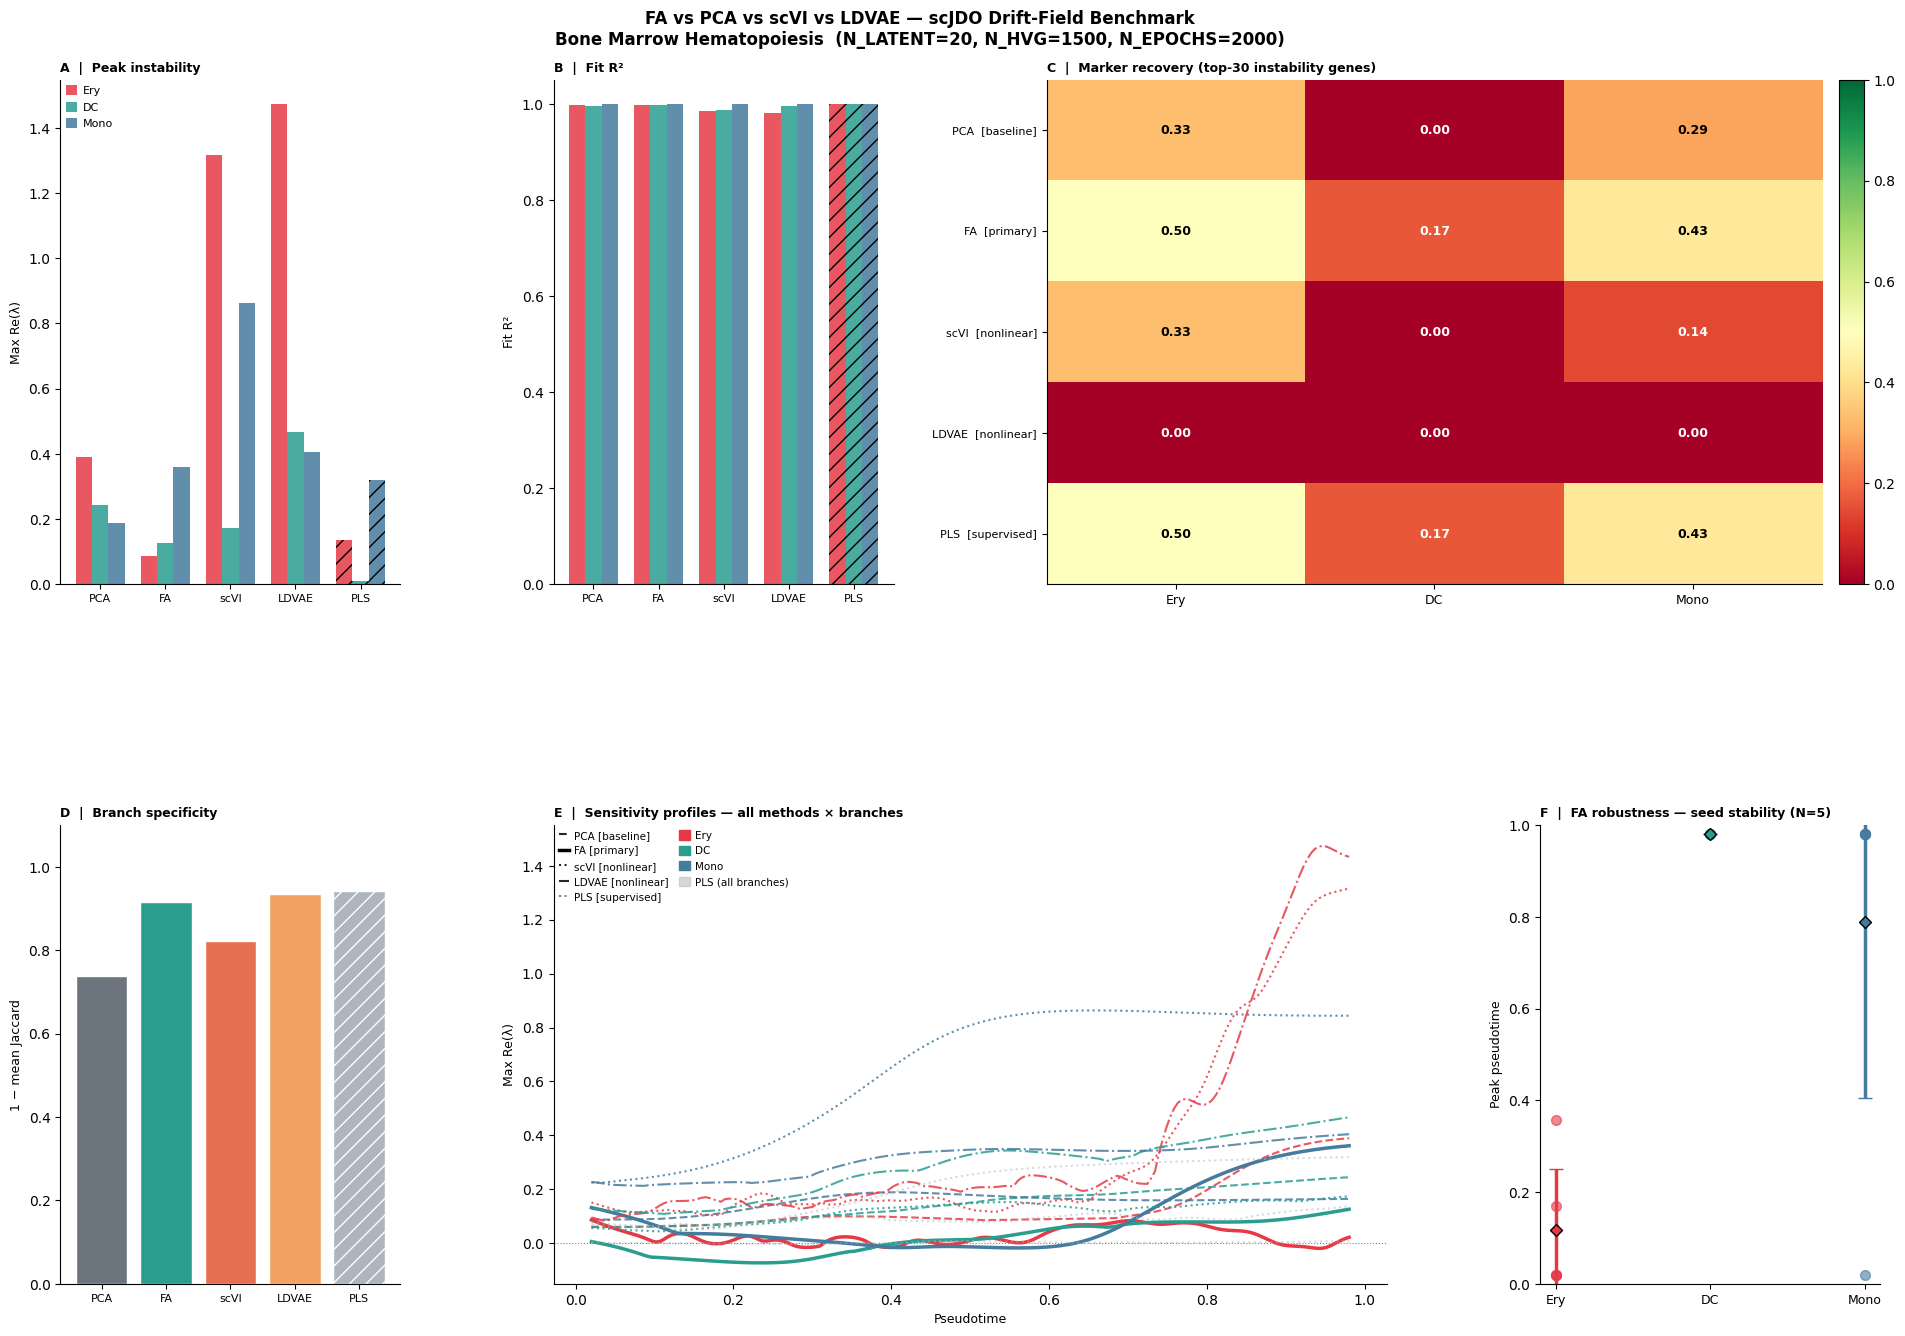

In [9]:
# Linestyle per method: FA solid, others dashed/dotted, PLS gray
LS  = {'PCA': '--', 'FA': '-', 'scVI': ':', 'LDVAE': '-.', 'PLS': ':'}
LW  = {'PCA': 1.5, 'FA': 2.5, 'scVI': 1.5, 'LDVAE': 1.5, 'PLS': 1.5}
ALPHA = {'PCA': 0.85, 'FA': 1.0, 'scVI': 0.85, 'LDVAE': 0.85, 'PLS': 0.5}

fig = plt.figure(figsize=(20, 14))
gs  = gridspec.GridSpec(
    2, 4,
    height_ratios=[1.1, 1.0],
    hspace=0.50, wspace=0.45,
    left=0.07, right=0.98, top=0.93, bottom=0.07,
)
ax_A = fig.add_subplot(gs[0, 0])    # A: peak max_eig per method x branch
ax_B = fig.add_subplot(gs[0, 1])    # B: fit R2
ax_C = fig.add_subplot(gs[0, 2:])   # C: marker recovery heatmap
ax_D = fig.add_subplot(gs[1, 0])    # D: branch specificity
ax_E = fig.add_subplot(gs[1, 1:3])  # E: sensitivity profiles
ax_F = fig.add_subplot(gs[1, 3])    # F: FA seed stability

n_m   = len(METHODS)
x_m   = np.arange(n_m)
bar_w = 0.25

def get_scalar(method, branch, key, default=0.0):
    res = ALL_RESULTS.get(method, {}).get(branch)
    if res is None: return default
    if key == 'max_real_eig': return float(res['max_real_eig'].max())
    return float(res.get(key, default))


# ─ A: Peak instability ───────────────────────────────────────────────────
for bi, branch in enumerate(BRANCHES):
    vals = [get_scalar(m, branch, 'max_real_eig') for m in METHODS]
    bars = ax_A.bar(x_m + (bi-1)*bar_w, vals, width=bar_w,
                    color=BRANCH_COLORS[branch], label=branch, alpha=0.85)
    for mi, (bar, m) in enumerate(zip(bars, METHODS)):
        if m in SUPERVISED_METHODS: bar.set_hatch('//')
ax_A.set_xticks(x_m); ax_A.set_xticklabels(METHODS, fontsize=8)
ax_A.axhline(0, color='gray', lw=0.8, ls=':')
ax_A.set_ylabel('Max Re(λ)', fontsize=9)
ax_A.legend(fontsize=8, loc='upper left')
ax_A.set_title('A  |  Peak instability', fontweight='bold', loc='left', fontsize=9)

# ─ B: Fit R2 ─────────────────────────────────────────────────────────────
for bi, branch in enumerate(BRANCHES):
    vals = [get_scalar(m, branch, 'r2') for m in METHODS]
    bars = ax_B.bar(x_m + (bi-1)*bar_w, vals, width=bar_w,
                    color=BRANCH_COLORS[branch], alpha=0.85)
    for mi, (bar, m) in enumerate(zip(bars, METHODS)):
        if m in SUPERVISED_METHODS: bar.set_hatch('//')
ax_B.set_xticks(x_m); ax_B.set_xticklabels(METHODS, fontsize=8)
ax_B.set_ylim(0, 1.05)
ax_B.set_ylabel('Fit R²', fontsize=9)
ax_B.set_title('B  |  Fit R²', fontweight='bold', loc='left', fontsize=9)

# ─ C: Marker recovery heatmap ─────────────────────────────────────────────
hm = np.array([[bio_df.loc[bio_df.method==m, b].values[0]
                 if (bio_df.method==m).any() else 0.0
                 for b in BRANCHES] for m in METHODS])
im = ax_C.imshow(hm, aspect='auto', vmin=0, vmax=1, cmap='RdYlGn')
ax_C.set_xticks(np.arange(len(BRANCHES))); ax_C.set_xticklabels(BRANCHES, fontsize=9)
ax_C.set_yticks(np.arange(n_m))
ylabels = [f'{m}  [{METHOD_ROLE[m]}]' for m in METHODS]
ax_C.set_yticklabels(ylabels, fontsize=8)
for i in range(n_m):
    for j in range(len(BRANCHES)):
        v = hm[i, j]
        ax_C.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=9,
                   color='black' if 0.2 < v < 0.8 else 'white', fontweight='bold')
plt.colorbar(im, ax=ax_C, fraction=0.05, pad=0.02)
ax_C.set_title(f'C  |  Marker recovery (top-{TOP_N} instability genes)',
                fontweight='bold', loc='left', fontsize=9)

# ─ D: Branch specificity ─────────────────────────────────────────────────
sv = [spec_df.loc[spec_df.method==m, 'specificity'].values[0]
      if (spec_df.method==m).any() else 0.0 for m in METHODS]
bar_colors_D = [METHOD_COLORS[m] for m in METHODS]
bars_D = ax_D.bar(x_m, sv, color=bar_colors_D, edgecolor='white')
for bar, m in zip(bars_D, METHODS):
    if m in SUPERVISED_METHODS: bar.set_hatch('//')
ax_D.set_xticks(x_m); ax_D.set_xticklabels(METHODS, fontsize=8)
ax_D.set_ylim(0, 1.1)
ax_D.set_ylabel('1 − mean Jaccard', fontsize=9)
ax_D.set_title('D  |  Branch specificity', fontweight='bold', loc='left', fontsize=9)

# ─ E: Sensitivity profiles ────────────────────────────────────────────────
for method in METHODS:
    br = ALL_RESULTS.get(method, {})
    for branch in BRANCHES:
        res = br.get(branch)
        if res is None: continue
        col = METHOD_COLORS[method] if method in SUPERVISED_METHODS else BRANCH_COLORS[branch]
        ax_E.plot(res['t_centers'], res['max_real_eig'],
                   color=col, ls=LS[method], lw=LW[method], alpha=ALPHA[method])
ax_E.axhline(0, color='gray', lw=0.8, ls=':')
ax_E.set_xlabel('Pseudotime', fontsize=9)
ax_E.set_ylabel('Max Re(λ)', fontsize=9)
ax_E.set_title('E  |  Sensitivity profiles — all methods × branches',
                fontweight='bold', loc='left', fontsize=9)
leg_method = [Line2D([0],[0], color='black', ls=LS[m], lw=LW[m],
                      alpha=ALPHA[m], label=f'{m} [{METHOD_ROLE[m]}]') for m in METHODS]
leg_branch = [Patch(color=BRANCH_COLORS[b], label=b) for b in BRANCHES]
leg_branch.append(Patch(color=METHOD_COLORS['PLS'], alpha=0.5, label='PLS (all branches)'))
ax_E.legend(handles=leg_method + leg_branch, fontsize=7.5, ncol=2, loc='upper left')

# ─ F: FA seed stability ────────────────────────────────────────────────────
for bi, branch in enumerate(BRANCHES):
    mean_pt, std_pt, pts = SEED_STABILITY[branch]
    ax_F.scatter([bi]*len(pts), pts, color=BRANCH_COLORS[branch], alpha=0.6, s=50, zorder=3)
    ax_F.errorbar(bi, mean_pt, yerr=std_pt, color=BRANCH_COLORS[branch],
                   capsize=5, lw=2.5, fmt='D', markeredgecolor='black', zorder=4)
ax_F.set_xticks(np.arange(len(BRANCHES))); ax_F.set_xticklabels(BRANCHES, fontsize=9)
ax_F.set_ylim(0, 1); ax_F.set_ylabel('Peak pseudotime', fontsize=9)
ax_F.set_title(f'F  |  FA robustness — seed stability (N={len(ROBUST_SEEDS)})',
                fontweight='bold', loc='left', fontsize=9)

fig.suptitle(
    f'FA vs PCA vs scVI vs LDVAE — scJDO Drift-Field Benchmark\n'
    f'Bone Marrow Hematopoiesis  '
    f'(N_LATENT={N_LATENT}, N_HVG={N_HVG}, N_EPOCHS={N_EPOCHS})',
    fontsize=12, fontweight='bold',
)
fig_path = OUTDIR + 'fa_benchmark_figure.pdf'
fig.savefig(fig_path, dpi=300, bbox_inches='tight')
print(f'Saved: {fig_path}')
plt.show()

In [10]:
SEP = '=' * 110
print(SEP)
print(f'{"Method":7s}  {"Role":12s}  {"Branch":6s}  {"max_λ":>8}  '
      f'{"peak_t":>7}  {"R2":>6}  {"markers%":>9}  {"specificity":>11}  Top-5 genes')
print('-' * 110)

for method in METHODS:
    br   = ALL_RESULTS.get(method, {})
    role = METHOD_ROLE[method]
    sv   = spec_df.loc[spec_df.method==method, 'specificity'].values[0] \
           if (spec_df.method==method).any() else float('nan')
    for branch in BRANCHES:
        res = br.get(branch)
        if res is None:
            print(f'{method:7s}  {role:12s}  {branch:6s}  FAILED'); continue
        pi   = np.argmax(res['max_real_eig'])
        me   = float(res['max_real_eig'][pi])
        pt   = float(res['t_centers'][pi])
        r2   = float(res.get('r2', float('nan')))
        mr   = bio_df.loc[bio_df.method==method, branch].values[0] \
               if (bio_df.method==method).any() else float('nan')
        top5 = ', '.join(res.get('top_instability_genes', [])[:5]) or 'none'
        print(f'{method:7s}  {role:12s}  {branch:6s}  {me:>8.4f}  '
              f'{pt:>7.3f}  {r2:>6.3f}  {100*mr:>8.0f}%  {sv:>11.3f}  {top5}')
    print()

print(SEP)
print('\nFA Robustness Summary:')
print(f'  Seed stability (N={len(ROBUST_SEEDS)} seeds):')
for b in BRANCHES:
    m, s, pts = SEED_STABILITY[b]
    print(f'    {b}: peak_t = {m:.3f} +/- {s:.4f}')

print(f'\n  Cell subsampling ({int(100*SUBSAMPLE_FRAC)}%, N={N_SUBSAMPLE_RUNS}):')
for b in BRANCHES:
    pts = [peak_t(r.get(b)) for r in CELL_SUB_RUNS if r.get(b) is not None]
    if pts: print(f'    {b}: {np.mean(pts):.3f} +/- {np.std(pts):.4f}')

print(f'\n  Gene subsampling ({N_GENE_SUBSAMPLE}/{N_HVG} HVGs, N={N_SUBSAMPLE_RUNS}):')
for b in BRANCHES:
    pts = [peak_t(r.get(b)) for r in GENE_SUB_RUNS if r.get(b) is not None]
    if pts: print(f'    {b}: {np.mean(pts):.3f} +/- {np.std(pts):.4f}')

print('\n  Perturbed progenitor quantile:')
for q, br in PERT_Q_RUNS.items():
    vals = '   '.join(f'{b}: {peak_t(br.get(b)):.3f}' for b in BRANCHES)
    print(f'    q={q:.2f}: {vals}')

bio_df.to_csv(OUTDIR + 'biology_check.csv', index=False)
spec_df.to_csv(OUTDIR + 'branch_specificity.csv', index=False)
print(f'\nCSVs saved to: {OUTDIR}')

Method   Role          Branch     max_λ   peak_t      R2   markers%  specificity  Top-5 genes
--------------------------------------------------------------------------------------------------------------
PCA      baseline      Ery       0.3891    0.980   0.998        33%        0.739  CD52, LGALS1, MPO, HOPX, BLVRB
PCA      baseline      DC        0.2446    0.980   0.996         0%        0.739  ATF7IP2, EREG, ELANE, NRIP1, YPEL5
PCA      baseline      Mono      0.1886    0.401   1.000        29%        0.739  C1QTNF4, HOPX, CD52, MPO, SLC40A1

FA       primary       Ery       0.0862    0.020   0.998        50%        0.916  FCER1A, HBB, APOC1, CA1, AHSP
FA       primary       DC        0.1258    0.980   0.998        17%        0.916  LGALS1, IRF8, TK1, PLD4, UHRF1
FA       primary       Mono      0.3612    0.980   1.000        43%        0.916  LYZ, LGALS1, CSTA, C1QTNF4, HOPX

scVI     nonlinear     Ery       1.3161    0.980   0.985        33%        0.822  HBB, BLVRB, CPA3, C1QTNF4